In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N_STEPS_DEFAULT = 1000
EPSILON_DEFAULT = 0.1
MARGIN_DEFAULT = 1e-6

# 1. Статистический анализ результатов прямого численного моделирования

(а) Определим процедуры обновления состояния `step_stochastic_em`, `step_stochastic_rk4`, задающие временной шаг стохастической системы, и запишем стохастические системы FHN и SN. В работе будем использовать стохастический метод Рунге-Кутты 4-го порядка для обновления состояния (процедура `step_stochastic_rk4`).

In [3]:
def step_stochastic_em(
    model_func: callable,
    params: dict,
    state: np.ndarray,
    dt: float,
    epsilon: float,
    noise_mask: np.ndarray = np.array([1, 1]),
    rng: np.random.Generator = np.random.default_rng(),
):
    """
    Euler-Maruyama step for stochastic system given by `model_func` with `params`.

    Args:
        dt: integration step
        epsilon: noise intensity (when set to 0, the system is considered deterministic)
        noise_mask: denotes the equations to which noise should be added (noise vector is multiplied by the noise mask element-wise)
    
    Returns:
        system state after the randomized step
    """
    drift = model_func(0, state, **params)
    
    dW = rng.normal(0., 1., size=2) * np.sqrt(dt)
    noise = epsilon * dW * noise_mask
    
    return state + drift * dt + noise


def step_stochastic_rk4(
    model_func: callable,
    params: dict,
    state: np.ndarray,
    dt: float,
    epsilon: float,
    noise_mask: np.ndarray,
    rng: np.random.Generator,
):
    """
    Runge-Kutta 4-th order step for stochastic system given by `model_func` with `params`.

    First, the deterministic RK4 step is performed, and then the computed state is augmented with the noise.

    Args:
        dt: integration step
        epsilon: noise intensity (when set to 0, the system is considered deterministic)
        noise_mask: denotes the equations to which noise should be added (noise vector is multiplied by the noise mask element-wise)
    
    Returns:
        system state after the randomized step
    """
    k1 = dt * model_func(0, state, **params)
    k2 = dt * model_func(0, state + k1/2, **params)
    k3 = dt * model_func(0, state + k2/2, **params)
    k4 = dt * model_func(0, state + k3, **params)
    
    state_rk = state + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    dW = rng.normal(0., 1., size=2) * np.sqrt(dt)
    noise = epsilon * dW * noise_mask

    return state_rk + noise

FHN с аддитивным шумом в 1-м уравнении:  
$$
\begin{cases}
    \dot{x} = \frac{1}{\delta} (x - \frac{x^3}{3} - y) + \varepsilon \cdot \xi_1 \\
    \dot{y} = x + a
\end{cases}
$$

In [4]:
def model_FHN(
    time: float,
    state: np.ndarray,
    delta: float = 0.1,
    a: float = 1,
):
    """
    FitzHugh-Nagumo neural model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - delta << 1 (delta = 0.1)
    - a > 0
    """
    x, y = state
    return np.array([
        (x - (x ** 3) / 3 - y) / delta,
        x + a
    ])

SN с аддитивным шумом в обоих уравнениях:  
$$
\begin{cases}
    \dot{x} = y - x + \varepsilon \cdot \xi_1 \\
    \dot{y} = -a x + b y - x^2 y + \varepsilon \cdot \xi_2
\end{cases}
$$

In [5]:
def model_SN(
    time: float,
    state: np.ndarray,
    a: float = 1,
    b: float = 2,
):
    """
    Saltzman-Nicolis climate model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - a > 0
    - b = 2
    """
    x, y = state
    return np.array([
        y - x,
        -a * x + b * y - (x ** 2) * y
    ])

(б) Для устойчивых равновесий построим облака случайных траекторий для разных значений интенсивности шума $\varepsilon$.

In [6]:
def simulate_trajectory(
    model_func: callable,
    params: dict,
    state_init: np.ndarray,
    time_span: np.ndarray,
    epsilon: float,
    noise_mask: np.ndarray,
    rng: np.random.Generator,
    method: str = 'rk4',   # 'em' for Euler-Maruyama step
):
    n = len(time_span)
    dt = time_span[1] - time_span[0]
    
    trajectory = np.zeros((n, 2))
    trajectory[0] = state_init
    
    if method == 'rk4':
        step_func = step_stochastic_rk4
    elif method == 'em':
        step_func = step_stochastic_em
    else:
        raise ValueError(f'Unknown step method: {method}!')

    for i in range(n - 1):
        trajectory[i + 1] = step_func(
            model_func=model_func,
            params=params,
            state=trajectory[i],
            dt=dt,
            epsilon=epsilon,
            noise_mask=noise_mask,
            rng=rng,
        )
    
    return trajectory


def simulate_stochastic_cloud(
    ax: plt.Axes,
    model_func: callable,
    params: dict,
    equilibrium: np.ndarray,
    time_span: np.ndarray,
    epsilon: float,
    noise_mask: np.ndarray,
    n_trajectories: int = 1,
    spread_init: float = 0.05,
):
    rng = np.random.default_rng()
    trajectories = []
    
    for _ in range(n_trajectories):
        # start near the equilirium
        state_init = equilibrium + rng.normal(0, spread_init, size=2)
        
        trajectory = simulate_trajectory(
            model_func=model_func,
            params=params,
            state_init=state_init,
            time_span=time_span,
            epsilon=epsilon,
            noise_mask=noise_mask,
            rng=rng,
        )
        trajectories.append(trajectory)

        if ax is not None:
            ax.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.3)
    
    if ax is not None:
        ax.scatter(*equilibrium, color='red', s=50, zorder=100, label='equilibrium')
        ax.set_title(f"Noise cloud ({epsilon=})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(loc="upper right")
        ax.grid(True)

    return trajectories

Облака траекторий системы FHN вблизи устойчивого равновесия $(\overline{x}, \overline{y}) = (-a, \frac{a^3}{3} - a)$ при $a > 1$:

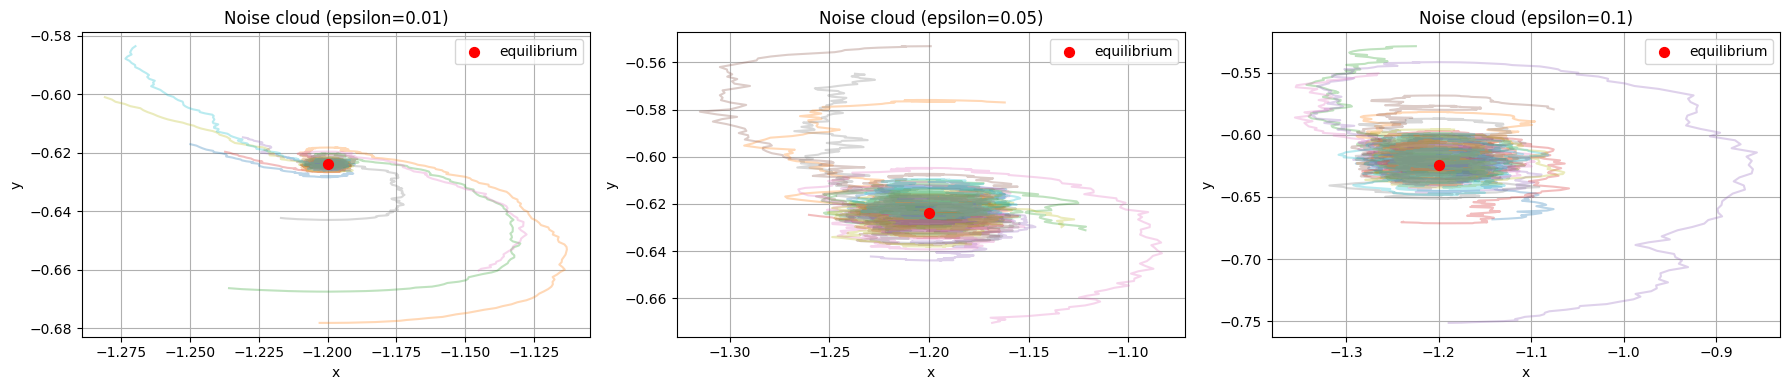

In [7]:
delta, a = 0.1, 1.2

equilibrium_expr = np.array([-a, a**3 / 3 - a])

noise_mask = np.array([1, 0])   # add noise to 1st equation only
epsilon_values = [0.01, 0.05, 0.1]

time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

fig, axes = plt.subplots(1, len(epsilon_values), figsize=(18, 4))

for ax, epsilon in zip(axes, epsilon_values):
    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium_expr,
        time_span=time_span,
        epsilon=epsilon,
        noise_mask=noise_mask,
        n_trajectories=10,
    )

plt.tight_layout()
plt.show()

Облака траекторий системы SN вблизи устойчивого равновесия $(\overline{x}, \overline{y}) = (\sqrt{b - a}, \sqrt{b - a})$:

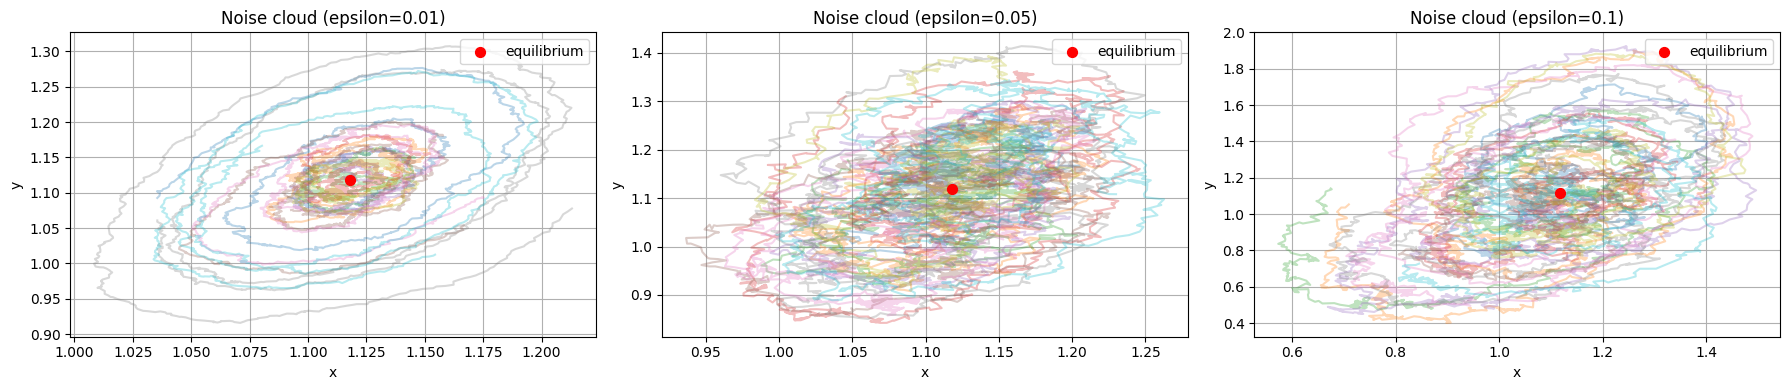

In [8]:
a, b = 0.75, 2

equilibrium_expr = np.array([np.sqrt(b - a), np.sqrt(b - a)])

noise_mask = np.array([1, 1])   # add noise to both equations
epsilon_values = [0.01, 0.05, 0.1]

time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

fig, axes = plt.subplots(1, len(epsilon_values), figsize=(18, 4))

for ax, epsilon in zip(axes, epsilon_values):
    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_SN,
        params=dict(a=a, b=b),
        equilibrium=equilibrium_expr,
        time_span=time_span,
        epsilon=epsilon,
        noise_mask=noise_mask,
        n_trajectories=10,
    )

plt.tight_layout()
plt.show()

(в) Запишем матрицу ковариации для облака при фиксированном $\varepsilon$, найдем ее собственные числа $\overline{\lambda_1}(a), \overline{\lambda_2}(a)$.

$$
\operatorname{cov}(x, y) =
\begin{pmatrix}
    \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2 & \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) \\
    \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) & \frac{1}{n} \sum_{i=1}^n (y_i - \bar{y})^2
\end{pmatrix}
$$

In [9]:
def compute_covariance_matrix_2d(
    trajectories: list[np.ndarray],
    clip_ratio: float = 0.5,
) -> np.ndarray:
    """
    Compute 2x2 covariance matrix for a stochastic cloud.

    Args:
        trajectories: list of trajectories of shape `(n_steps, 2)`
    
    Returns:
        cov_matrix: covariance matrix
        points_concat: stochastic cloud after clipping the transient
    """
    points = []
    
    for trajectory in trajectories:
        # clip transient (consider only the asymptotic behavior of the system)
        clip = int(len(trajectory) * clip_ratio)
        traj_stationary = trajectory[clip:]
        points.append(traj_stationary)
    
    points_concat = np.vstack(points)  # shape (N_total, 2)
    cov_matrix = np.cov(points_concat.T)
    
    return cov_matrix

Построим графики зависимостей $\overline{\lambda_1}(a), \overline{\lambda_2}(a)$ в зоне устойчивых равновесий $(a_1, a_2)$. Будем использовать значение $\varepsilon = 0.1$.

Будем использовать от $1$ до $100$ симуляций и $10^3$ шагов по времени в каждой из них, таким образом получим графики для выборок размеров $N = 1 \cdot 10^3$ и $N = 100 \cdot 10^3$.

In [10]:
def plot_eigenvalues_per_param_value(
    ax: plt.Axes,
    model_func: callable,
    params: dict,
    equilibrium_expr: callable,
    time_span: np.ndarray,
    param_name: str,
    param_values: np.ndarray,
    stable_range: tuple[float, float],
    epsilon: float = 0.1,
    noise_mask: np.ndarray = np.array([1, 1]),
    covariance: bool = True,
    n_trajectories: int = 1,
):
    """
    Plot eigenvalues of the covariance matrix (or analytically derived stochastic sensitivity matrix) at
    different values `param_values` of a given parameter `param_name`.

    Args:
        equilibrium_expr: function, which returns equilibrium point at given model parameter values
        stable_range: parameter range, where given equilibrium remains stable
        epsilon: noise intensity (when set to 0, the system is considered deterministic)
        noise_mask: denotes the equations to which noise should be added (noise vector is multiplied by the noise mask element-wise)
        covariance: whether to use covariance matrix on a simulation instead of analytically derived stochastic sensitivity matrix
        n_trajectories: number of simulations (unused if `covariance` is False, i.e. analytical method is used)
    """
    lambda1_values = []
    lambda2_values = []

    for val in param_values:
        params[param_name] = val
        equilibrium = equilibrium_expr(val)

        if covariance:
            trajectories = simulate_stochastic_cloud(
                ax=None,
                model_func=model_func,
                params=params,
                equilibrium=equilibrium,
                time_span=time_span,
                epsilon=epsilon,
                noise_mask=noise_mask,
                n_trajectories=n_trajectories
            )
            matrix = compute_covariance_matrix_2d(trajectories)
            eigenvalues = np.linalg.eigvals(matrix)
        else:
            matrix = stochastic_sensitivity_matrix_2d(  # TODO: defined later in the notebook, and not visible here
                model_func=model_func,
                params=params,
                equilibrium=equilibrium,
                noise_mask=noise_mask,
            )
            eigenvalues = np.linalg.eigvals(matrix) * epsilon ** 2
        
        lambda1_values.append(eigenvalues[0])
        lambda2_values.append(eigenvalues[1])

    ax.axvspan(*stable_range, color='green', alpha=0.3, label='stable equilibria')
    ax.plot(param_values, lambda1_values, label=rf'$\lambda_1({param_name})$')
    ax.plot(param_values, lambda2_values, label=rf'$\lambda_2({param_name})$')

    ax.set_xlabel(param_name)
    ax.set_ylabel('eigenvalues')
    ax.legend(loc='upper right')
    ax.grid(True)

В модели FHN при значении параметра $a > 1$ равновесие $(x, y) = (0, 0)$ устойчиво.

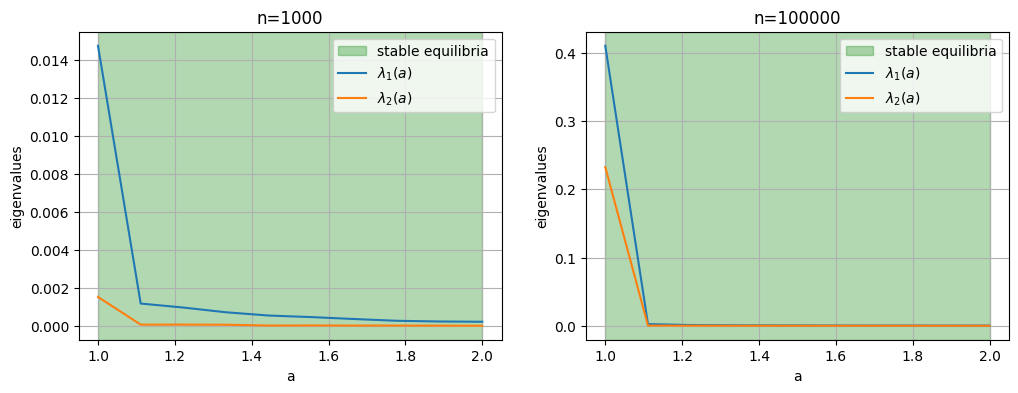

In [11]:
delta, a = 0.1, None    # `a` is a variable parameter

noise_mask = np.array([1, 0])   # add noise to 1st equation only

time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

param_name = 'a'
param_values = np.linspace(1 + MARGIN_DEFAULT, 2, num=10)

def equilibrium_expr(a):
    return np.array([-a, a**3 / 3 - a])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, n_trajectories in zip(axes, [1, 100]):
    plot_eigenvalues_per_param_value(
        ax=ax,
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium_expr=equilibrium_expr,
        time_span=time_span,
        param_name=param_name,
        param_values=param_values,
        stable_range=(param_values[0], param_values[-1]),
        epsilon=EPSILON_DEFAULT,
        noise_mask=noise_mask,
        covariance=True,
        n_trajectories=n_trajectories
    )
    ax.set_title(f'n={n_trajectories * N_STEPS_DEFAULT}')

В модели SN при значении параметра $a < 1$ устойчивыми являются равновесия:

$$
(\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
(\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
$$

Вблизи них система ведет себя одинаково с точностью до симметрии. Рассмотрим одно из них, например $(\overline{x}_2, \overline{y}_2)$.

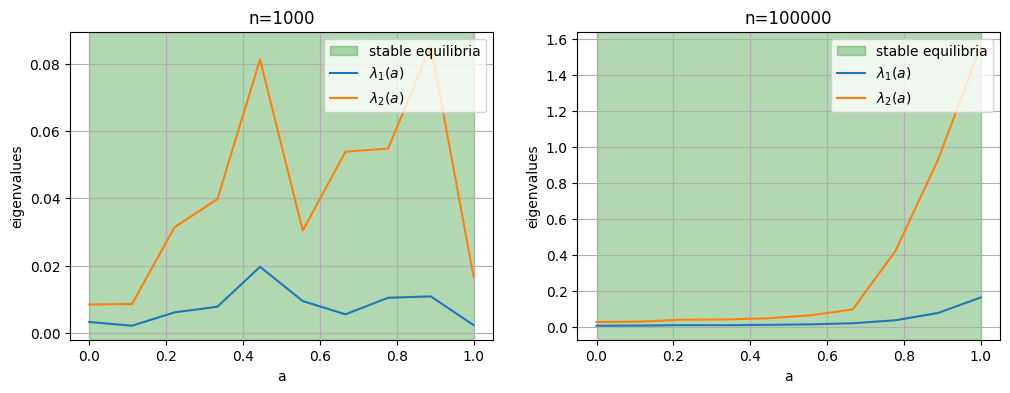

In [12]:
a, b = None, 2    # `a` is a variable parameter

noise_mask = np.array([1, 1])   # add noise to both equations

param_name = 'a'
param_values = np.linspace(0, 1 - MARGIN_DEFAULT, num=10)

time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

def equilibrium_expr(a):
    return np.array([np.sqrt(b - a), np.sqrt(b - a)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, n_trajectories in zip(axes, [1, 100]):
    plot_eigenvalues_per_param_value(
        ax=ax,
        model_func=model_SN,
        params=dict(a=a, b=b),
        equilibrium_expr=equilibrium_expr,
        time_span=time_span,
        param_name=param_name,
        param_values=param_values,
        stable_range=(param_values[0], param_values[-1]),
        epsilon=EPSILON_DEFAULT,
        noise_mask=noise_mask,
        covariance=True,
        n_trajectories=n_trajectories,
    )
    ax.set_title(f'n={n_trajectories * N_STEPS_DEFAULT}')

# 2. Анализ с помощью метода стохастической чувствительности
(а) Запишем решение уравнения Ляпунова в общем виде.

$$
F W + W F^T + S S^T = 0
$$

С учетом изначальной формы СДУ:

$$
\begin{cases}
    \dot{x} = f(x, y) + \varepsilon \sigma_1(x, y) \xi_1 \\
    \dot{y} = g(x, y) + \varepsilon \sigma_2(x, y) \xi_2
\end{cases}
$$

Имеем
$$
S = 
\begin{pmatrix}
    \sigma_1(x, y) & 0 \\
    0 & \sigma_2(x, y)
\end{pmatrix}

\implies

SS^T = 
\begin{pmatrix}
    \sigma_1^2(x, y) & 0 \\
    0 & \sigma_2^2(x, y)
\end{pmatrix}
= 
\begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
$$

$$
F = 
\begin{pmatrix}
    f'_x(x, y) & f'_y(x, y) \\
    g'_x(x, y) & g'_y(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    a & b \\
    c & d
\end{pmatrix}
$$

$$
W = 
\begin{pmatrix}
    w_1 & w_2 \\
    w_2 & w_3
\end{pmatrix}
$$

Тогда уравнение (3) имеет вид:

$$
\begin{pmatrix}
    a & b \\
    c & d
\end{pmatrix}
\begin{pmatrix}
    w_1 & w_2 \\
    w_2 & w_3
\end{pmatrix}
+
\begin{pmatrix}
    w_1 & w_2 \\
    w_2 & w_3
\end{pmatrix}
\begin{pmatrix}
    a & c \\
    b & d
\end{pmatrix}
+
\begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
= 0
$$

$$
\begin{pmatrix}
    a w_1 + b w_2 & a w_2 + b w_3 \\
    c w_1 + d w_2 & c w_2 + d w_3
\end{pmatrix}
+
\begin{pmatrix}
    a w_1 + b w_2 & c w_1 + d w_2 \\
    a w_2 + b w_3 & c w_2 + d w_3
\end{pmatrix}
=
- \begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
$$

$$
\begin{pmatrix}
    2a w_1 + 2b w_2 & cw_1 + (a+d)w_2 + bw_3 \\
    cw_1 + (a+d)w_2 + bw_3 & 2c w_2 + 2d w_3
\end{pmatrix}
=
- \begin{pmatrix}
    s_1 & 0 \\
    0 & s_2
\end{pmatrix}
$$

В силу симметрии матриц в левой и правой частях, получаем систему из 3-х уравнений:
$$
\begin{cases}
   2a w_1 + 2b w_2 = -s_1 \\
   c w_1 + (a+d) w_2 + b w_3 = 0 \\
   2c w_2 + 2d w_3 = -s_2
\end{cases}
\implies
\begin{cases}
    w_1 = -\frac{s_1 + 2b w_2}{2a} \\
    w_3 = -\frac{s_2 + 2c w_2}{2d} \\
    -c \cdot \frac{s_1 + 2b w_2}{2a} + (a + d) w_2 - b \cdot \frac{s_2 + 2c w_2}{2d} = 0
\end{cases}
$$

Решение относительно $w_1, w_2, w_3$:

$$
w_2 = \frac{
    \frac{c s_1}{2a} + \frac{b s_2}{2c}
}{
    a + d - \frac{b c}{a} - \frac{b c}{d}
}
$$

$$
w_1 = -\frac{s_1 + 2b w_2}{2a}
$$

$$
w_3 = -\frac{s_2 + 2c w_2}{2d}
$$

Получено явное решение, но для удобства программного решения можно представить полученную систему уравнений в матричной форме:

$$
\begin{pmatrix}
    2a & 2b & 0 \\
    c & a+d & b \\
    0 & 2c & 2d
\end{pmatrix}

\begin{pmatrix}
    w_1 \\ w_2 \\ w_3
\end{pmatrix}
=
\begin{pmatrix}
    -s_1 \\ 0 \\ -s_2
\end{pmatrix}
$$

In [13]:
def find_jacobian(
    func: callable,
    t: float,
    state: np.ndarray,
    params: dict,
    eps: float = 1e-6,
) -> np.ndarray:
    n = len(state)
    jacobian = np.zeros((n, n))

    for i in range(n):
        perturb = np.zeros(n)
        perturb[i] = eps
        
        f1 = func(t, state + perturb, **params)
        f2 = func(t, state - perturb, **params)
        jacobian[:, i] = (f1 - f2) / (2 * eps)
    
    return jacobian


def solve_lyapunov_symmetric_2d(F: np.ndarray, Q: np.ndarray):
    """
    Solve Lyapunov equation $F W + W F^T + Q = 0$ for 2D symmetric matrix W (stochastic sensitivity matrix)
    and noise matrix Q ($Q = S S^T$).

    The equation is represented in a matrix form with respect to variables w_1, w_2, w_3.

    Notes:
        F = [[f'_x(x, y), f'_y(x, y)],
            [g'_x(x, y), g'_y(x, y)]]

        W = [[w_1, w_2],
            [w_2, w_3]]
    """
    a, b = F[0, 0], F[0, 1]
    c, d = F[1, 0], F[1, 1]

    q11 = Q[0, 0]
    q12 = Q[0, 1]
    q22 = Q[1, 1]

    A = np.array([
        [2*a, 2*b, 0],
        [c, a+d, b],
        [0, 2*c, 2*d],
    ], dtype=float)

    rhs = -np.array([q11, q12, q22], dtype=float)

    w1, w2, w3 = np.linalg.solve(A, rhs)

    W = np.array([
        [w1, w2],
        [w2, w3]
    ])

    return W


def stochastic_sensitivity_matrix_2d(
    model_func: callable,
    params: dict,
    equilibrium: np.ndarray,
    noise_mask: np.ndarray = np.array([1, 1]),
):
    """
    Find stochastic sensitivity matrix `W` near the `equilibrium` point for a dynamic system given by `model_func` with parameter values `params`.
    """
    F = find_jacobian(func=model_func, t=0, state=equilibrium, params=params)
    eigenvalues = np.linalg.eigvals(F)

    if np.any(np.real(eigenvalues) >= 0):
        raise ValueError(f"Equilibrium is not asymptotically stable at {params=}. Eigenvalues: {eigenvalues}")

    S = np.array([
        [noise_mask[0], 0.],
        [0., noise_mask[1]]
    ])
    Q = S @ S.T
    W = solve_lyapunov_symmetric_2d(F, Q)

    return W

Запишем матрицу стохастической чувствительности $W$ для FHN, где

$$
Q = SS^T = 
\begin{pmatrix}
    \sigma_1^2(x, y) & 0 \\
    0 & \sigma_2^2(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    1 & 0 \\
    0 & 0
\end{pmatrix}
$$

$$
F = 
\begin{pmatrix}
    f'_x(x, y) & f'_y(x, y) \\
    g'_x(x, y) & g'_y(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    \frac{1}{\delta} (1 - x^2) & \frac{1}{\delta} \\
    1 & 0
\end{pmatrix}
$$

In [14]:
delta, a = 0.1, 2
noise_mask = np.array([1, 0])
equilibrium_expr = np.array([-a, a**3 / 3 - a])
W = stochastic_sensitivity_matrix_2d(
    model_func=model_FHN,
    params=dict(delta=delta, a=a),
    equilibrium=equilibrium_expr,
    noise_mask=noise_mask,
)

W

array([[ 0.01666667, -0.        ],
       [-0.        ,  0.00166667]])

Запишем матрицу стохастической чувствительности $W$ для SN, где

$$
Q = SS^T = 
\begin{pmatrix}
    \sigma_1^2(x, y) & 0 \\
    0 & \sigma_2^2(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    1 & 0 \\
    0 & 1
\end{pmatrix}
$$

$$
F = 
\begin{pmatrix}
    f'_x(x, y) & f'_y(x, y) \\
    g'_x(x, y) & g'_y(x, y)
\end{pmatrix}
=
\begin{pmatrix}
    -1 & 1 \\
    -a - 2xy & b - x^2
\end{pmatrix}
$$

In [ ]:
a, b = 0.5, 2
noise_mask = np.array([1, 1])
equilibrium_expr = np.array([np.sqrt(b - a), np.sqrt(b - a)])
W = stochastic_sensitivity_matrix_2d(
    model_func=model_SN,
    params=dict(a=a, b=b),
    equilibrium=equilibrium_expr,
    noise_mask=noise_mask,
)
W

array([[1.41666667, 0.91666667],
       [0.91666667, 5.41666667]])

(б) Найдем собственные числа $\lambda_1, \lambda_2$ матрицы стохастической чувствительности $W$.

Построим зависимость $\varepsilon \cdot \lambda_1(a), \varepsilon \cdot \lambda_2(a)$ для $\varepsilon$ из пункта 1 (б) для системы FHN.

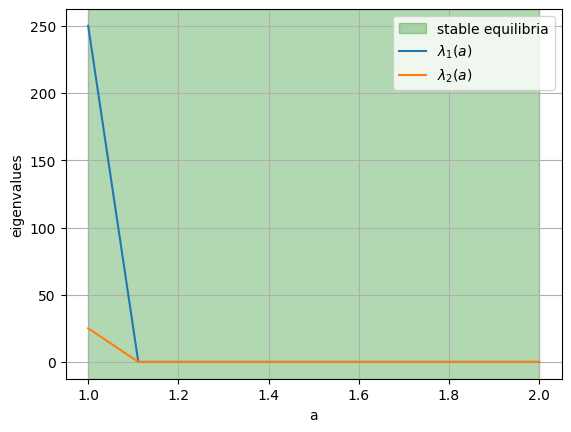

In [16]:
delta, a = 0.1, None    # `a` is a variable parameter

noise_mask = np.array([1, 0])   # add noise to 1st equation only

param_name = 'a'
param_values = np.linspace(1 + MARGIN_DEFAULT, 2, num=10)

time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

def equilibrium_expr(a):
    return np.array([-a, a**3 / 3 - a])

fig, ax = plt.subplots()

plot_eigenvalues_per_param_value(
    ax=ax,
    model_func=model_FHN,
    params=dict(delta=delta, a=a),
    equilibrium_expr=equilibrium_expr,
    time_span=time_span,
    param_name=param_name,
    param_values=param_values,
    stable_range=(param_values[0], param_values[-1]),
    epsilon=EPSILON_DEFAULT,
    noise_mask=noise_mask,
    covariance=False,
)

Построим зависимость $\varepsilon \cdot \lambda_1(a), \varepsilon \cdot \lambda_2(a)$ для $\varepsilon$ из пункта 1 (б) для системы SN.

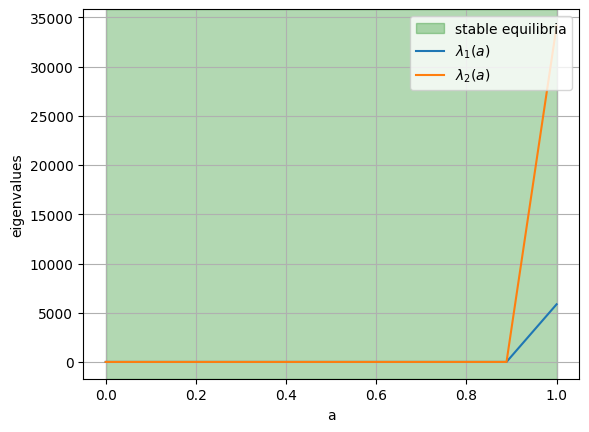

In [17]:
a, b = None, 2    # `a` is a variable parameter

noise_mask = np.array([1, 1])   # add noise to both equations

param_name = 'a'
param_values = np.linspace(0, 1 - MARGIN_DEFAULT, num=10)

time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

def equilibrium_expr(a):
    return np.array([np.sqrt(b - a), np.sqrt(b - a)])

fig, ax = plt.subplots()

plot_eigenvalues_per_param_value(
    ax=ax,
    model_func=model_SN,
    params=dict(a=a, b=b),
    equilibrium_expr=equilibrium_expr,
    time_span=time_span,
    param_name=param_name,
    param_values=param_values,
    stable_range=(param_values[0], param_values[-1]),
    epsilon=EPSILON_DEFAULT,
    noise_mask=noise_mask,
    covariance=False,
)

Полученные графики схожи с графиками из пункта 1 (в), построенными эмпирически с помощью симуляции, по характеру изменения собственных значений вблизи границ интервала стабильности равновесных точек (зеленая зона). Однако при вычислении аналитическим путем графики получаются менее плавные, и более резко начинают возрастать на границах интервала стабильности.

## Доверительные эллипсы
(в) Для выбранных нескольких значений параметра $a$ построим доверительные эллипсы (возьмем облако из пункта 1 (б)).

В двумерном случае матрица стохастической чувствительности $W$ характеризует дисперсию решений стохастической системы вокруг устойчивого равновесия $\overline{x} = (\overline{x_1}, \overline{x_2})$ в форме доверительного эллипса:

$$
\frac{z_1^2}{\lambda_1} + \frac{z_2^2}{\lambda_2} = 2k^2 \varepsilon^2
$$

Пусть $\lambda_1, \lambda_2$ -- собственные числа матрицы $W$, а $V$ -- матрица собственных векторов $v_1 = (v_{11}, v_{21})^T$, $v_2 = (v_{12}, v_{22})^T$, записанных по столбцам:

$$
V = \begin{pmatrix} v_{11} & v_{12} \\ v_{21} & v_{22} \end{pmatrix}
$$

Координаты $x = (x_1, x_2)$ доверительного эллипса в базисе собственных векторов могут быть записаны так:

$$
x = \overline{x} + V \cdot \begin{pmatrix} z_1 \\ z_2 \end{pmatrix},
$$
где $z_1(\varphi) = \sqrt{2\lambda_1} \cdot \varepsilon \cdot k \cdot \cos\varphi$, $z_2(\varphi) = \sqrt{2\lambda_2} \cdot \varepsilon \cdot k \cdot \sin\varphi$ ($0 \leq \varphi \leq 2\pi$).

Коэффициент $k$ связан с доверительной вероятностью $P$ попадания решений стохастической системы в доверительный эллипс:

$$
k = \sqrt{-\ln(1 - P)}
$$

In [18]:
def plot_confidence_ellipse_2d(
    ax: plt.Axes,
    equilibrium: np.ndarray,
    W: np.ndarray,
    epsilon: float,
    confidence: float = 0.95,
    n_points: int = 100,
    major_axes: bool = False,
):
    """
    Plot confidence ellipse for a 2D stochastic system based on the
    stochastic sensitivity matrix W.

    Vectorized and numerically correct version.
    
    Args:
        ax: Matplotlib axes to plot on
        equilibrium : equilibrium point (x, y) of the deterministic system
        W: 2x2 stochastic sensitivity matrix
        epsilon: noise intensity
        confidence: confidence probability P (0 < P < 1)
        n_points: number of points to generate the ellipse using the parameterized space
    """
    eigenvalues, eigenvectors = np.linalg.eigh(W)
    
    idx_sorted = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx_sorted]
    eigenvectors = eigenvectors[:, idx_sorted]
    
    lambda1, lambda2 = eigenvalues
    
    if lambda1 <= 0 or lambda2 <= 0:
        raise ValueError("W must be positive definite")
    
    phi = np.linspace(0, 2 * np.pi, n_points)
    circle = np.vstack((np.cos(phi), np.sin(phi)))
    
    k = np.sqrt(-np.log(1 - confidence))
    axis_scales = np.array([
        np.sqrt(2 * lambda1),
        np.sqrt(2 * lambda2)
    ]) * epsilon * k
    
    # Translate ellipse points into a basis formed by the eigenvectors of W
    ellipse_local = axis_scales[:, None] * circle
    ellipse = eigenvectors @ ellipse_local
    ellipse += equilibrium.reshape(2, 1)
    
    ax.plot(ellipse[0], ellipse[1], 'b--', label='confidence ellipse')
    
    if major_axes:
        for i in range(2):
            axis_length = axis_scales[i]
            v = eigenvectors[:, i]
            
            p1 = equilibrium - axis_length * v
            p2 = equilibrium + axis_length * v
            
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'c--')
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='upper right')
    ax.grid(True)

Построим доверительные эллипсы для системы FHN. Рассмотрим несколько значений параметра $a$ внутри интервала, где рассматриваемое равновесие сохраняет устойчивость.

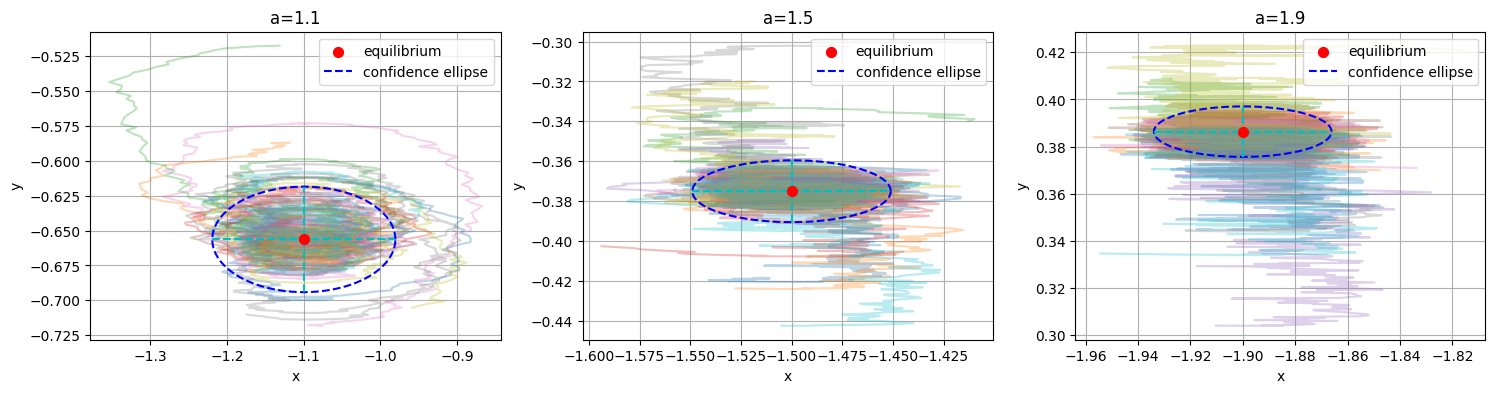

In [23]:
delta, a = 0.1, 1.2
noise_mask = np.array([1, 0])

param_name = 'a'
param_values = [1.1, 1.5, 1.9]

confidence = 0.95
time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

fig, axes = plt.subplots(1, len(param_values), figsize=(18, 4))

for ax, val in zip(axes, param_values):
    a = val
    equilibrium_expr = np.array([-a, a**3 / 3 - a])
    W = stochastic_sensitivity_matrix_2d(
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium_expr,
        noise_mask=noise_mask,
    )

    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium_expr,
        time_span=time_span,
        epsilon=EPSILON_DEFAULT,
        noise_mask=noise_mask,
        n_trajectories=10,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium_expr,
        W=W,
        epsilon=EPSILON_DEFAULT,
        confidence=confidence,
        major_axes=True,
    )
    ax.set_title(f'{a=}')

Построим доверительные эллипсы для системы SN. Рассмотрим несколько значений параметра $a$ внутри интервала, где рассматриваемое равновесие сохраняет устойчивость.

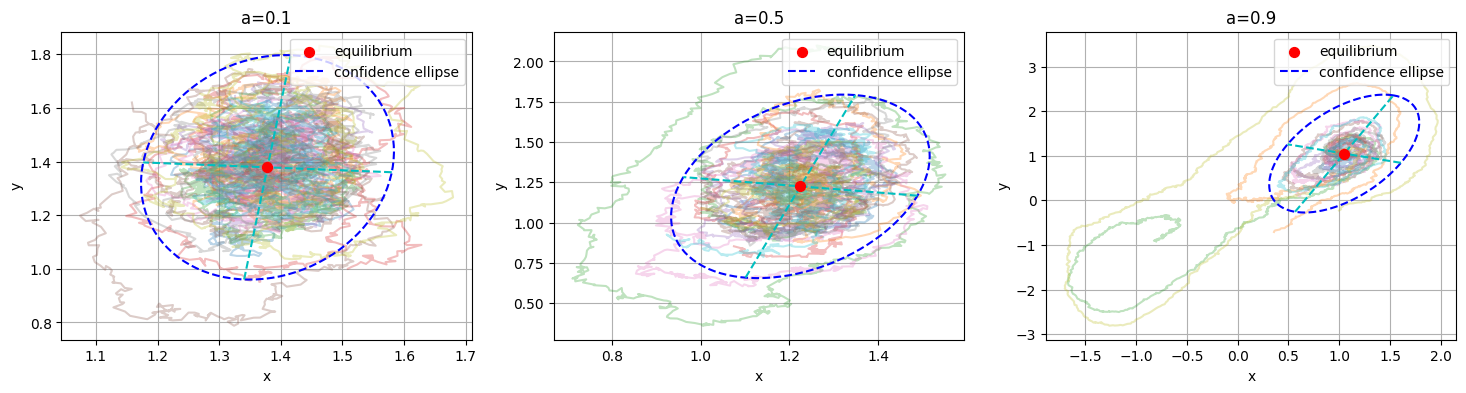

In [30]:
a, b = 0.75, 2
noise_mask = np.array([1, 1])   # add noise to both equations

param_name = 'a'
param_values = [0.1, 0.5, 0.9]

confidence = 0.95
time_span = np.linspace(0, 10, N_STEPS_DEFAULT)

fig, axes = plt.subplots(1, len(param_values), figsize=(18, 4))

for ax, val in zip(axes, param_values):
    a = val
    equilibrium_expr = np.array([np.sqrt(b - a), np.sqrt(b - a)])
    W = stochastic_sensitivity_matrix_2d(
        model_func=model_SN,
        params=dict(a=a, b=b),
        equilibrium=equilibrium_expr,
        noise_mask=noise_mask,
    )

    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_SN,
        params=dict(a=a, b=b),
        equilibrium=equilibrium_expr,
        time_span=time_span,
        epsilon=EPSILON_DEFAULT,
        noise_mask=noise_mask,
        n_trajectories=10,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium_expr,
        W=W,
        epsilon=EPSILON_DEFAULT,
        confidence=confidence,
        major_axes=True,
    )
    ax.set_title(f'{a=}')

# TODO
- Удостовериться, что при симуляции облака траккторий, все траектории стартуют строго в равновесии
- Построить графики собственных чисел матрицы стохастической чувствительности и матрицы ковариации (теоретический и эмпирический) рядом на одном графике и сравнить
- Построить графиик собственных чисел в логарифмической шкале, чтобы было видно колебания от 0 до 1, а не только вблизи границ интервала устойчивости равновесия (возможно, также уменьшить шаг разбиения)